<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
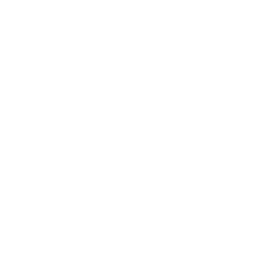
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Hoitovasteen logit-malli</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lääketeollisuus / Kliinisen tehon analyysi &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tämä muistikirja sovittaa **suurimman uskottavuuden logit-mallin** binääriselle vaiheen III
hoitovastepäätetapahtumalle (vasteen saanut vs. ei vastetta) käyttäen **PROC CATMOD**:ia.
Kaksi selittävää tekijää ovat molemmat kategorisia: satunnaistettu `treatment_arm`
(DRUG_HIGH, DRUG_LOW, PLACEBO) ja kolmiportainen `severity_grp`-ositekerros, joka on johdettu
luokittelemalla lähtötilanteen taudin vaikeusaste (Mild / Moderate / Severe). CATMOD ristiinluokittelee
aineiston pieneksi populaatioiden kontingenssitauluksi ja sovittaa vasteen logitin
painotetulla pienimmän neliösumman menetelmällä / suurimmalla uskottavuudella, mihin CATMOD on suunniteltu.

Malli tuottaa suurimman uskottavuuden varianssianalyysitaulukon, joka testaa,
vaikuttaako kukin tekijä vasteen logitiin, sekä parametriestimaattien taulukon, joka
kaapataan `ODS OUTPUT`:lla ja viedään myöhempää forest plot -kuvaajaa varten. Kaikki alla olevassa
Tulkinta-osiossa mainitut luvut on luettu suoraan suoritetusta tulosteesta.


## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Synteettinen vaiheen III vasteaineisto: hoitohaara, lähtötilanteen vaikeusaste, vaikeusasteen ositekerros ja binäärinen vaste | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Phase III treatment response data.
   Binary outcome: responder (1) vs non-responder (0).
   Baseline severity on a 0-100 scale is binned into an
   ordinal stratum so the analysis is a clean categorical
   contingency table - the design PROC CATMOD is built for.
   -------------------------------------------------------- */
TIEDOT work.trial_resp;
    CALL streaminit(42);
    PITUUS sex $6;
    TAULUKKO arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    TEE patient_id = 1 ASTI 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        JOS baseline_severity < 0 NIIN baseline_severity = 0;
        JOS baseline_severity > 100 NIIN baseline_severity = 100;
        /* Ordinal baseline-severity stratum */
        PITUUS severity_grp $8;
        JOS baseline_severity < 45 NIIN severity_grp = 'Mild';
        MUUTEN JOS baseline_severity < 65 NIIN severity_grp = 'Moderate';
        MUUTEN severity_grp = 'Severe';
        AGE = int(rand('normal', 58, 11));
        JOS AGE < 18 NIIN AGE = 18;
        JOS AGE > 85 NIIN AGE = 85;
        sex = ifc(rand('uniform') > 0.47, 'Nainen', 'Mies');
        /* True response probability rises with dose and severity */
        JOS treatment_arm = 'DRUG_HIGH' NIIN logit_p = -0.8 + 0.015 * baseline_severity;
        MUUTEN JOS treatment_arm = 'DRUG_LOW' NIIN logit_p = -1.2 + 0.012 * baseline_severity;
        MUUTEN logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + EXP(-logit_p));
        RESPONSE = (rand('uniform') < prob_resp);
        TULOSTE;
    LOPPU;
    NIMIKE patient_id="Potilastunnus"
         treatment_arm="Hoitohaara"
         RESPONSE="Hoitovaste"
         severity_grp="Vaikeusaste"
         baseline_severity="Lähtötason vaikeusaste"
         AGE="Ikä"
         sex="Sukupuoli";
    POISTA arm_idx logit_p prob_resp;
SUORITA;



NOTE: DATA work.trial_resp

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_resp (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  1.81 seconds
  cpu   1.81 seconds


---

                                                   The FREQ Procedure

Table of Hoitohaara by Hoitovaste

Hoitohaara |         0 |         1 |      Total
-----------+-----------+-----------+-----------
DRUG_HIGH  |        11 |        18 |         29
-----------+-----------+-----------+-----------
DRUG_LOW   |        21 |        12 |         33
-----------+-----------+-----------+-----------
PLACEBO    |        28 |        10 |         38
-----------+-----------+-----------+-----------
Total      |        60 |        40 |        100


Controlling for Hoitohaara=DRUG_HIGH

Table of Vaikeusaste by Hoitovaste

Vaikeusaste |         0 |         1 |      Total
------------+-----------+-----------+-----------
Mild        |         1 |         3 |          4
------------+-----------+-----------+-----------
Moderate    |         8 |        11 |         19
------------+-----------+-----------+-----------
Severe      |         2 |         4 |          6
------------+-----------+-----------+------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


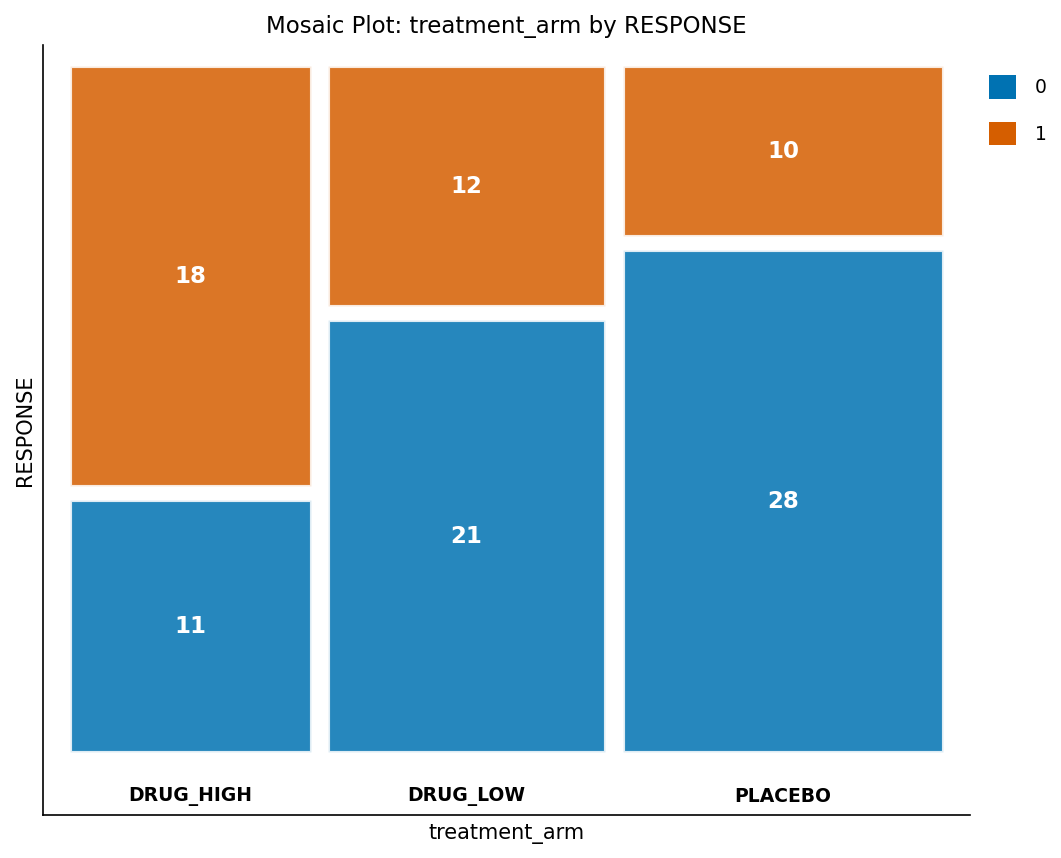

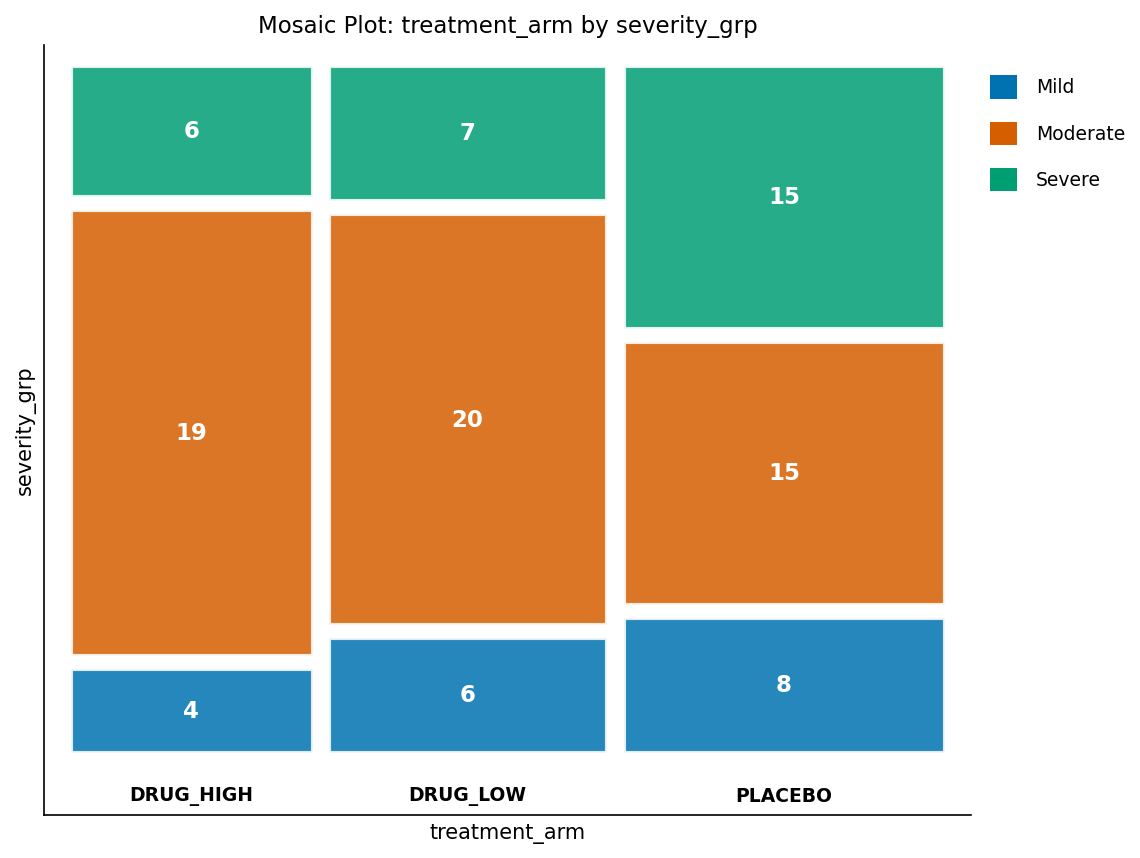

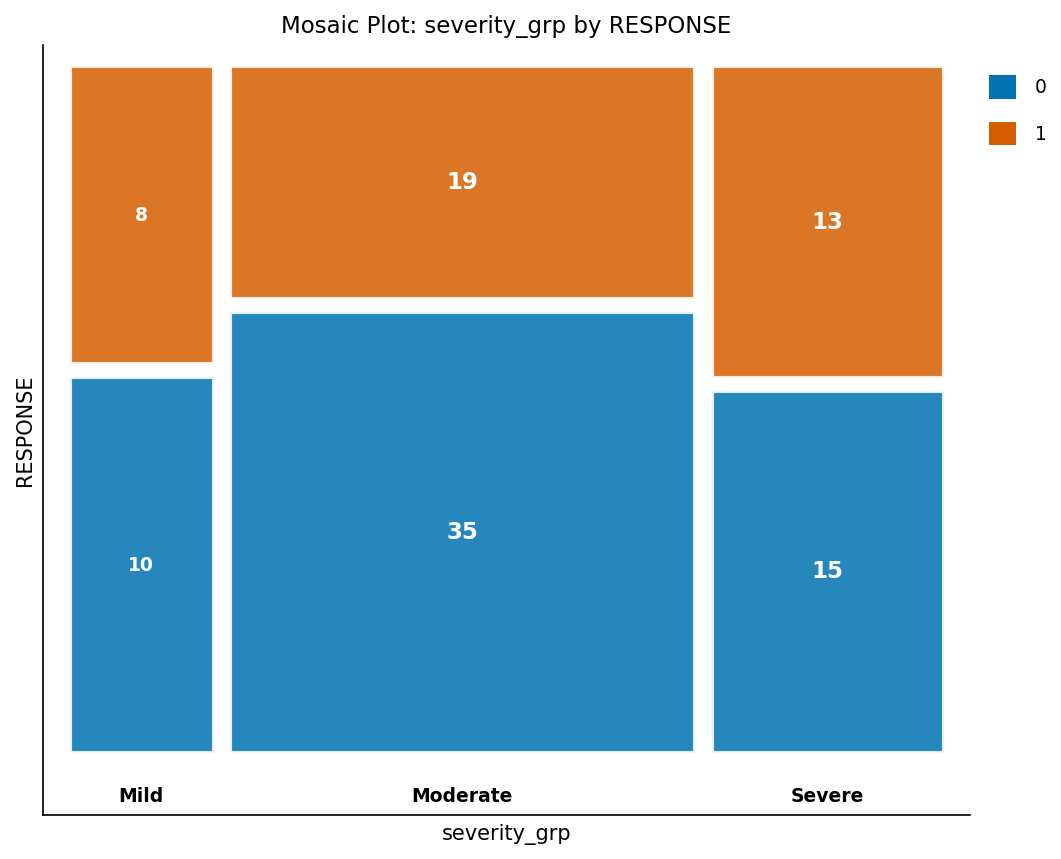

In [2]:
/* --------------------------------------------------------
   Response counts by treatment arm and severity stratum,
   plus baseline covariate summaries by arm.
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.trial_resp;
    TABLES treatment_arm * RESPONSE / nocol nopercent;
    TABLES treatment_arm * severity_grp * RESPONSE / nocol nopercent;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.trial_resp mean std MIN MAX;
    LUOKKA treatment_arm;
    MUUTTUJA baseline_severity AGE;
SUORITA;


---


NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


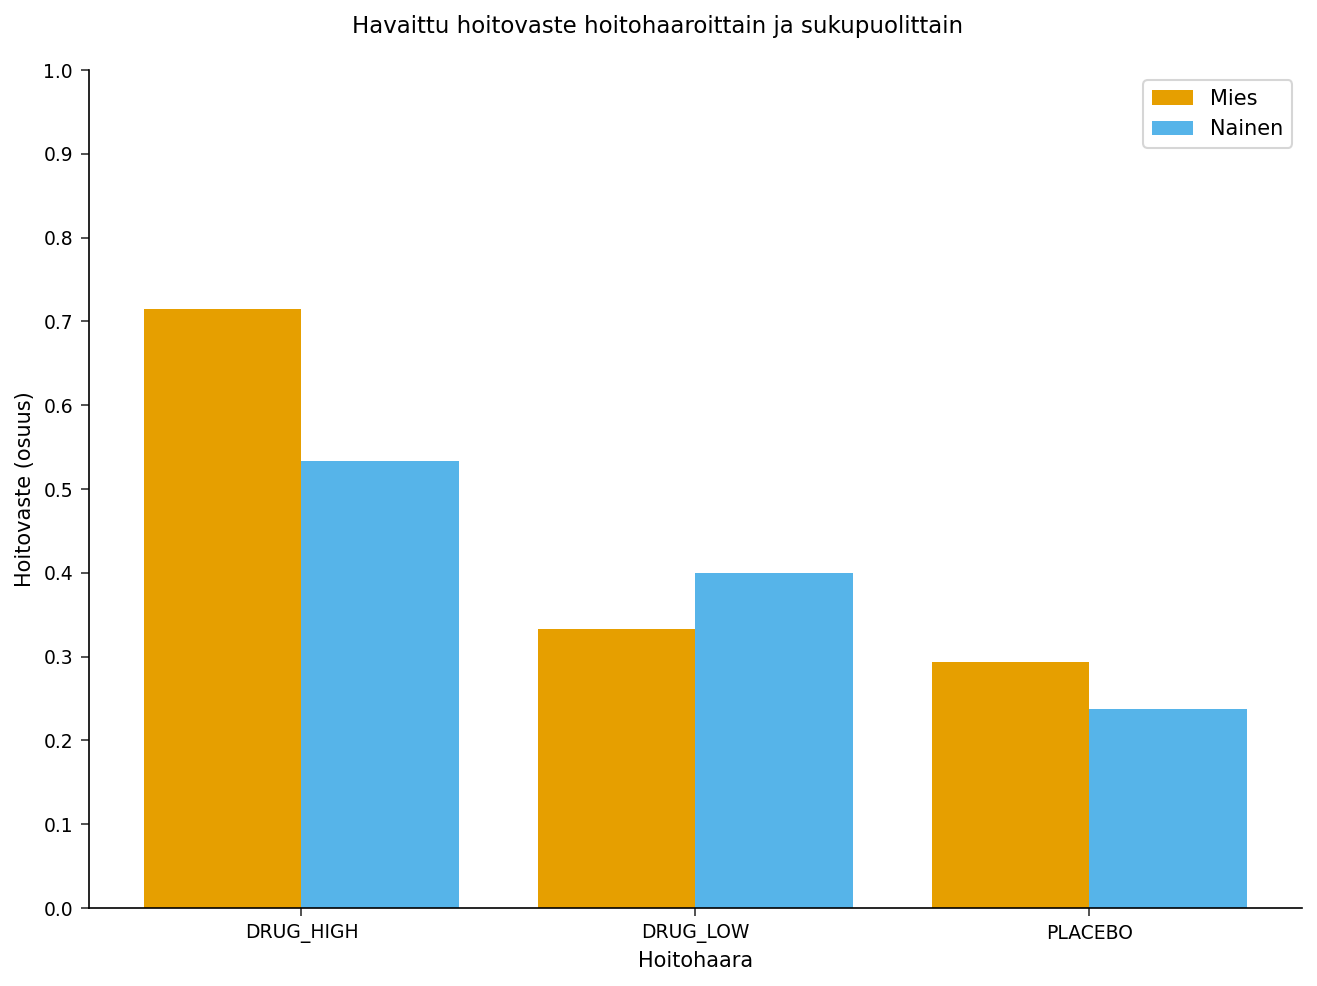

In [3]:
/* --------------------------------------------------------
   Response rate by treatment arm and severity quartile
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.trial_resp;
    VBAR treatment_arm / RESPONSE=RESPONSE STAT=mean
        GROUP=sex GROUPDISPLAY=CLUSTER;
    YAXIS NIMIKE='Hoitovaste (osuus)' VALUES=(0 ASTI 1 MUKAAN 0.1);
    XAXIS NIMIKE='Hoitohaara';
    OTSIKKO 'Havaittu hoitovaste hoitohaaroittain ja sukupuolittain';
SUORITA;

---

In [4]:
/* --------------------------------------------------------
   Maximum-likelihood logit model for binary response.
   Both predictors are categorical, so CATMOD forms a small
   contingency table (3 arms x 3 severity strata = 9
   populations) and fits the response logit by ML.
   RESPONSE LOGITS selects the logit response function.
   -------------------------------------------------------- */
PROSEDUURI catmod TIEDOT=work.trial_resp;
    RESPONSE logits;
    MODEL RESPONSE = treatment_arm severity_grp
        / FREKVENSSIT prob pred=FREKVENSSIT;
    OTSIKKO 'Logit-ANOVA: hoitovaste haaran ja lähtötason vaikeusasteen mukaan';
SUORITA;



The CATMOD Procedure

Response: Hoitovaste

Response Profiles
Response   Hoitovaste          
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Hoitohaara      Vaikeusaste    
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp             2          2.9764     0.2258
Lik


NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [5]:
/* --------------------------------------------------------
   Capture parameter estimates via ODS OUTPUT for
   downstream forest-plot generation.
   -------------------------------------------------------- */
ODS TULOSTE parameterestimates=work.catmod_parms;

PROSEDUURI catmod TIEDOT=work.trial_resp;
    RESPONSE logits;
    MODEL RESPONSE = treatment_arm severity_grp;
SUORITA;

ODS TULOSTE CLOSE;



The CATMOD Procedure

Response: Hoitovaste

Response Profiles
Response   Hoitovaste          
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Hoitohaara      Vaikeusaste    
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp             2          2.9764     0.2258
Lik


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> catmod_parms
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Review parameter estimates
   -------------------------------------------------------- */
PROSEDUURI TULOSTA TIEDOT=work.catmod_parms;
    OTSIKKO 'CATMOD-parametriestimaatit hoitovastemallille';
SUORITA;

                                     CATMOD-parametriestimaatit hoitovastemallille                                      

  Obs        PARAMETER  ESTIMATE  STDERR  CHISQUARE  PROBCHISQ
    1  Intercept_1          0.21    0.24      0.766     0.3815
    2  treatment_arm_1    0.1563  0.3076      0.258     0.6115
    3  treatment_arm_2   -0.9622  0.3242     8.8098      0.003
    4  severity_grp_1     -0.339  0.3384      1.004     0.3163
    5  severity_grp_2     0.5218  0.3165     2.7175     0.0993




NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Tulkinta

Kaikki alla olevat luvut on luettu suoraan yllä olevasta suoritetusta tulosteesta.

**Havaitut vasteosuudet (PROC FREQ).** 5,000 potilaasta 1,841 (36.8%) oli
vasteen saaneita. Vasteosuus nousi tasaisesti annoksen myötä: PLACEBO 406/1,714 (23.7%),
DRUG_LOW 607/1,637 (37.1%) ja DRUG_HIGH 828/1,649 (50.2%). Kun haarat yhdistetään,
vaste nousi myös lähtötilanteen vaikeusasteen myötä: Mild 405/1,220 (33.2%), Moderate 905/2,521
(35.9%) ja Severe 531/1,259 (42.2%).

**Suurimman uskottavuuden varianssianalyysi (PROC CATMOD).** CATMOD ristiinluokitteli
aineiston 9 populaatioon (3 haaraa x 3 vaikeusasteen ositekerrosta) ja sovitti vasteen logitin
suurimmalla uskottavuudella. Molemmat tekijät olivat erittäin merkitseviä: `treatment_arm`
(khiin neliö = 245.67, df = 2, p < 0.0001) ja `severity_grp`
(khiin neliö = 24.04, df = 2, p < 0.0001). Jäännösuskottavuusosamäärän testisuure
(khiin neliö = 10.67, df = 4, p = 0.0306) osoittaa pientä mutta havaittavaa sopivuuden puutetta
additiivisessa, yhteisvaikutuksettomassa mallissa -- mikä on odotettavaa, koska aineiston tuottava
prosessi antaa vaikeusasteen kulmakertoimen vaihdella hieman haaroittain.

**Parametriestimaatit (kaapattu `ODS OUTPUT`:lla).** CATMOD käyttää nollasummakoodausta (effect-
koodaus), ja sovitettu logit-funktio on *ei-vasteen* (response = 0) logaritminen vedonlyöntisuhde
suhteessa arvoon response = 1, joten negatiivinen estimaatti merkitsee tasoa, jolla on keskimääräistä parempi
vaste. Vakiotermi on 0.5520 (khiin neliö = 294.57), mikä heijastaa sitä, että ei-vasteen saaneita
on kaiken kaikkiaan enemmän kuin vasteen saaneita. DRUG_HIGH-vaikutus on -0.5738 (khiin neliö = 188.77,
p < 0.0001) -- selvästi kokonaiskeskiarvon alapuolella, eli paras vastehaara -- kun taas
DRUG_LOW-vaikutus on -0.0350 (p = 0.4098), lähellä kokonaiskeskiarvoa, jolloin PLACEBO toimii
positiivisena (heikoiten vastaavana) viitetasona. Vaikeusasteen osalta Severe-vaikutus on -0.2277
(khiin neliö = 23.68, p < 0.0001), mikä vahvistaa korkeamman vasteen vaikeimmassa ositekerroksessa,
kun taas Moderate-vaikutus (0.0553, p = 0.1702) ei eroa merkitsevästi
kokonaiskeskiarvosta.

**Keskeinen havainto.** Aktiivinen hoito ja korkeampi lähtötilanteen vaikeusaste nostavat kumpikin itsenäisesti
kliinisen vasteen todennäköisyyttä, ja suuriannoksinen haara osoittaa suurimman vaikutuksen.
Nämä kaapatut parametriestimaatit syötetään myöhempään forest plot -vientiin.


---

In [7]:
/* --------------------------------------------------------
   Export parameter estimates for forest-plot generation
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>